In [96]:
#Data importation
import os
path_to_data = r"C:\Users\StartKlar\Documents\Msc_Thesis\Data\Las_Files_Boerholes\MB1\\"
files = os.listdir(path_to_data)
print(files)
file_atv_am = files[4]
file_otv = files [6]


['2020_07_30_ATV_ST2_Ampl_to192m_up.las', '2020_07_30_ATV_ST2_TravelT_to192m_up.las', '2020_08_01_SGR40_ATV_ampl_ST2_up.las', '2020_08_01_SGR40_ATV_TravelT_ST2_up.las', 'ST2_20210525_ATV_Amplitude_to350m_up_zcorr.las', 'ST2_20210525_ATV_travelT_to350m_up_zcorr.las', 'ST2_20210525_OTV_up_zcorr.las']


In [105]:
# import and read the data ATV
from deeplogger.image_processing import *
from deeplogger.importLASv3 import *
depth_ATV_am = get_depth_only(file_name=file_atv_am, #you can also just put the number of the data location in the files list, which is "files[10]" for the amplitude MB3 and "files[5]" for the travel time MB3
               data_path=path_to_data)

depth_subset_ATV, data_subset_ATV, index = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[62.00,63.00])
data_subset_ATV = data_subset_ATV.astype(float)



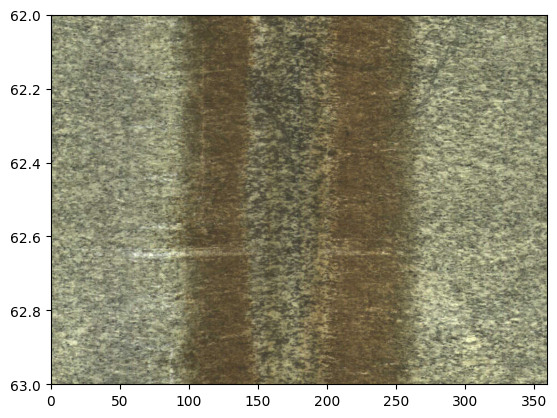

In [106]:
#data importation OTV : 

depth_subset_OTV = get_depth_only(file_name=file_otv,
               data_path=path_to_data)

depth_subset_OTV, data_subset_otv, index = get_data_subset_from_depth_range(file_name=file_otv,
                                                                    data_path=path_to_data,
                                                                    data_type='otv',
                                                                    depth_range=[62.00,63.00])
depth_vector_atv = depth_subset_ATV
depth_vector_otv = depth_subset_OTV
plt.imshow(data_subset_otv, extent=[0, 359, 63.00,62.00], aspect='auto')

### functions for labelling

In [8]:
import numpy as np
import pandas as pd

def filter_labels_from_range(label_df: pd.DataFrame,
                             filter_type: str,
                             filter_range: (list, tuple)):
    '''Filter the label dataframe based on entries of individual columns that have numeric values (e.g., depth and aperture).
    The dataframe returned has only the filtered values between the desired range.
    Args:
        label_df: label dataframe
        filter_type: column name of the dataframe to filter
        filter_range: range of values to filter
    Returns:
        label_df: filtered label dataframe

        '''
    # check if filter type exists in dataframe columns, otherwise return empty dataframe
    if filter_type not in label_df.columns:
        print('Filter type does not exist in dataframe columns')
        return pd.DataFrame()
    # check if filter range is a list or tuple with two entries, otherwise return empty dataframe
    if not isinstance(filter_range, (list, tuple)) or len(filter_range) != 2:
        print('Filter range must be a list or tuple with two entries')
        return pd.DataFrame()
    # filter based on filter type and range
    return label_df[(label_df[filter_type] >= filter_range[0]) & (label_df[filter_type] <= filter_range[1])].copy()


def find_nearest(array, value):
    """Find the nearest value in an array.
    Args:
        array: array to search
        value: value to search for
    Returns:
        idx: index of the nearest value in the array
            """
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def crop_depth(Z_up, Z_down, depth):
    """Crop the depth of the picks to the depth of the borehole.
    Args:
        Z_up: depth of the top of the pick
        Z_down: depth of the bottom of the pick
        depth: depth vector of the borehole
    Returns:
        Z_up: depth of the top of the pick cropped to the depth of the borehole
        Z_down: depth of the bottom of the pick cropped to the depth of the borehole
        """
    max_depth = depth[-2]
    min_depth = depth[2]
    Z_up[Z_up > max_depth] = max_depth
    Z_down[Z_down > max_depth] = max_depth
    Z_up[Z_up < min_depth] = min_depth
    Z_down[Z_down < min_depth] = min_depth
    return Z_up, Z_down


def get_label(azimuth: float,
              dip: float,
              depth: float,
              aperture: float,
              depth_vector: np.array,
              bh_diameter: float,
              azimuth_values: int = 360):
    """Get a label for a pick in the form of a rasterized image.
    Args:
        azimuth: azimuth of the pick in degrees
        dip: dip of the pick in degrees
        depth: mean depth of the pick
        aperture: aperture of the pick in mm
        depth_vector: depth vector of the borehole
        bh_diameter: borehole diameter in meters
        azimuth_values: number of azimuth values to use for the pick
    Returns:
        im: rasterized image of the pick
        """
    # convert aperture to meters
    aperture = aperture / 1000
    # if mean depth is outside the depth vector, then the pick is not valid
    azimuth_radians = np.linspace(0, 2 * np.pi, azimuth_values)
    azimuth_range = range(azimuth_values)
    amplitude = depth + np.sin(azimuth_radians + np.deg2rad(azimuth + 90)) * np.tan(np.deg2rad(dip)) * bh_diameter / 2
    Z_up = amplitude + aperture / 2
    Z_down = amplitude - aperture / 2
    Z_up, Z_down = crop_depth(Z_up, Z_down, depth_vector)
    im = np.zeros((depth_vector.shape[0], azimuth_values))
    if np.array(Z_up == Z_down).all():
        im[np.digitize(Z_up, depth_vector), azimuth_range] = 1
    else:
        Z_up_M = np.tile(Z_up, (depth_vector.shape[0], 1))
        Z_down_M = np.tile(Z_down, (depth_vector.shape[0], 1))
        Z_M = np.tile(depth_vector, (azimuth_values, 1)).T
        im[np.logical_and(Z_M < Z_up_M, Z_M > Z_down_M)] = 1
    return im

def get_pick_coordinates(alpha,
                         beta,
                         mean_depth,
                         depth_vector,
                         aperture: float = 1.0,
                         bh_diameter: float = 0.1,
                         azimuth_values: int = 360,):
    azimuth_degrees = np.linspace(0, 2 * np.pi, azimuth_values) + np.pi
    amplitude = np.tan(np.deg2rad(90) - alpha) * bh_diameter/2
    #        Z = -amplitude*np.cos(azimuth) + mean_depth
    Z = amplitude * np.cos(azimuth_degrees + beta) + mean_depth
    Z_up = Z + aperture / 2
    Z_down = Z - aperture / 2
    Z_up, Z_down = crop_depth(Z_up, Z_down, depth_vector)
    depth_index = np.arange(0, depth_vector.shape[0])
    depth_index[np.digitize(Z_up, depth_vector)]
    pixeled_line_up = depth_index[np.digitize(Z_up, depth_vector)]
    pixeled_line_down = depth_index[np.digitize(Z_down, depth_vector)]
    depth_pixels = np.concatenate((pixeled_line_up, np.flip(pixeled_line_down)))
    #        angle_pixels = np.concatenate((azimuth_degrees,np.flip(azimuth_degrees)))
    angle_pixels = np.concatenate((np.flip(azimuth_degrees), azimuth_degrees))
    coordinates = list(zip(angle_pixels, depth_pixels))
    return coordinates

def get_polygons(label_df, depth_vector):
    from shapely import Polygon
    polygons = list()
    polygon_colors = list()
    for index, label in enumerate(label_df):
#        polygon_colors.append(get_color(label[4]))
        print('Accessing label # ' + str(index))
        coordinates = digitize_label(label, depth_vector, index)
        polygons.append(Polygon(coordinates))
    return polygons

def raster_map_from_label(polygons, n_rows, n_cols):
    from rasterio import features
    return features.rasterize(polygons, (n_rows, n_cols), all_touched=True)


def dnorm(x, mu, sd):
    return 1 / (np.sqrt(2 * np.pi) * sd) * np.e ** (-np.power((x - mu) / sd, 2) / 2)


def gaussian_kernel(size, sigma=1):
    kernel_1D = np.linspace(-(size // 2), size // 2, size)
    for i in range(size):
        kernel_1D[i] = dnorm(kernel_1D[i], 0, sigma)
    kernel_2D = np.outer(kernel_1D.T, kernel_1D.T)
    kernel_2D *= 1.0 / kernel_2D.max()
    return kernel_2D


def convolution(image, kernel, average=False):
    image_row, image_col = image.shape
    kernel_row, kernel_col = kernel.shape

    output = np.zeros(image.shape)

    pad_height = int((kernel_row - 1) / 2)
    pad_width = int((kernel_col - 1) / 2)

    padded_image = np.zeros((image_row + (2 * pad_height), image_col + (2 * pad_width)))

    padded_image[pad_height:padded_image.shape[0] - pad_height,
    pad_width:padded_image.shape[1] - pad_width] = image

    for row in range(image_row):
        for col in range(image_col):
            output[row, col] = np.sum(kernel * padded_image[row:row + kernel_row, col:col + kernel_col])
            if average:
                output[row, col] /= kernel.shape[0] * kernel.shape[1]
    return output


def gaussian_blur(image, kernel_size):
    kernel = gaussian_kernel(kernel_size, sigma=np.sqrt(kernel_size))
    conv = convolution(image, kernel, average=False)
    return conv/conv.max()








In [99]:
#label definition
label = get_label(azimuth=244.21,
                  dip=75.65,
                  depth=62.81,
                  aperture=10,
                  depth_vector=depth_vector_atv,
                  bh_diameter=0.1,
                  azimuth_values=360)
label_otv = get_label(azimuth=244.21,
                  dip=75.65,
                  depth=62.81,
                  aperture=10,
                  depth_vector=depth_vector_otv,
                  bh_diameter=0.1,
                  azimuth_values=360)

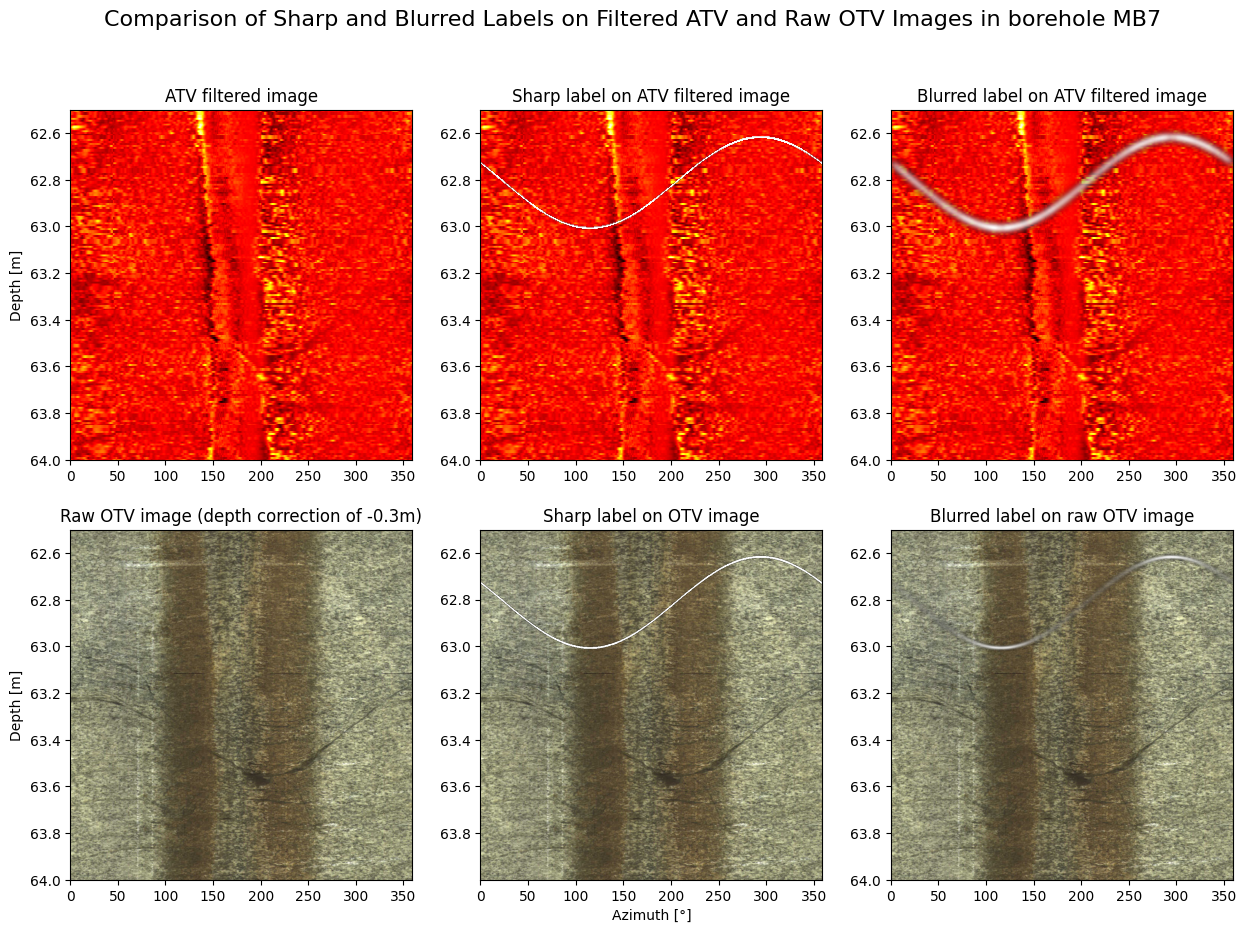

In [100]:
#Plotting cell
# tries plot with the filtered ATV image (SVD)
data_subset_svd_am = data_subset_svd_am, svd_decomp_am = remove_svd(data_subset_ATV, low_s=0, high_s=2)

#tries for plotting
import numpy as np
import matplotlib.pyplot as plt

data_subset_svd_am = replace_empty_measurements(data_subset_svd_am, 0)
# %% Plot the results and compare with a blurred mask
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].imshow(data_subset_svd_am, aspect='auto', extent=[0, 359, 64.0,62.5], cmap='hot')
axs[0,0].set_ylabel('Depth [m]')
axs[0,0].set_title('ATV filtered image')

labels_raw_ATV = label
# Your existing imshow code
axs[0,1].imshow(data_subset_svd_am,
                aspect='auto',
               extent=[0, 359, 64.0,62.5],
                cmap='hot')
axs[0,1].imshow(labels_raw_ATV,
                aspect='auto',
               extent=[0, 359, 64.0,62.5],
                alpha=labels_raw_ATV,
                cmap='grey')


axs[0,1].set_title('Sharp label on ATV filtered image')

# Blur the label with a gaussian kernel

label1_blurred_atv = gaussian_blur(label, kernel_size=19)
labels_blurred_ATV = label1_blurred_atv 

axs[0,2].imshow(data_subset_svd_am, aspect='auto', extent=[0, 359, 64.0,62.5], cmap='hot')
axs[0,2].imshow(labels_blurred_ATV, aspect='auto', extent=[0, 359, 64.0,62.5], cmap='grey',
                alpha=labels_blurred_ATV)
axs[0,2].set_title('Blurred label on ATV filtered image')

# plot normal label on OTV
axs[1,0].imshow(data_subset_otv, aspect='auto', extent=[0, 359, 64.0,62.5])
axs[1,0].set_ylabel('Depth [m]')
axs[1,0].set_title('Raw OTV image (depth correction of -0.3m)')


labels_raw_OTV = label_otv
axs[1,1].imshow(data_subset_otv, aspect='auto', extent=[0, 359, 64.0,62.5])
axs[1,1].imshow(labels_raw_OTV,
             cmap='grey',
              aspect='auto',
              extent=[0, 359, depth_vector_otv.max(), depth_vector_otv.min()],
              alpha=labels_raw_OTV)
axs[1,1].set_title('Sharp label on OTV image')
axs[1,1].set_xlabel('Azimuth [°]')
# Plot data_subset_atv with blurred label
label1_blurred_otv = gaussian_blur(label_otv, kernel_size=19)


labels_blurred_OTV = label1_blurred_otv
axs[1,2].imshow(data_subset_otv, 
                aspect='auto', 
                extent=[0, 359, 64.0,62.5])
axs[1,2].imshow(labels_blurred_OTV, 
                aspect='auto', 
                extent=[0, 359, 64.0,62.5],
# use the labels matrix as a tranparency mask for plotting the image
# add a command to choose the colormap for the labels
                cmap='grey',
                alpha = labels_blurred_OTV)

# zoom into the image to see the blurred label
#axs[1,1].set_xlim(50, 150)
#axs[1,1].set_ylim(158.8, 158.4)
axs[1,2].set_title('Blurred label on raw OTV image')

# Plot a column of the image before and after blurring with transparency
#axs[1, 1].plot(depth_vector_atv, label[:, 180], label='Original', alpha=1, color='black')
#axs[1, 1].plot(depth_vector_atv, label_blurred[:, 180], label='Blurred', alpha=0.5, color='red')
#axs[1, 1].legend()
#axs[1, 1].set_xlabel('Depth [m]')
#axs[1, 1].set_ylabel('Probability')
#axs[1, 1].set_xlim(118, 120)
plt.suptitle('Comparison of Sharp and Blurred Labels on Filtered ATV and Raw OTV Images in borehole MB7', fontsize=16)

plt.show()
#OTV = ATV - 0.3 m


In [66]:
# tries for other labellings
# data importation ATV
from deeplogger.image_processing import *
from deeplogger.importLASv3 import *
depth_subset_ATV = get_depth_only(file_name=file_atv_am, #you can also just put the number of the data location in the files list, which is "files[10]" for the amplitude MB3 and "files[5]" for the travel time MB3
               data_path=path_to_data)

depth_subset_ATV, data_subset_ATV, index = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[176.90,178.40])
data_subset_ATV = data_subset_ATV.astype(float)




In [67]:
#data importation OTV : 

depth_subset_OTV = get_depth_only(file_name=file_otv,
               data_path=path_to_data)

depth_subset_OTV, data_subset_otv, index = get_data_subset_from_depth_range(file_name=file_otv,
                                                                    data_path=path_to_data,
                                                                    data_type='otv',
                                                                    depth_range=[176.50,178.00])
depth_vector_atv = depth_subset_ATV
depth_vector_otv = depth_subset_OTV


C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\internals\managers.py:1752: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
C:\Users\StartKlar\AppData\Roaming\Python\Python312\site-packages\pandas\core\interna

In [68]:
from deeplogger.image_processing import *
from deeplogger.plotting import *

from scipy.ndimage import gaussian_filter

# Generate labels
label1_atv = get_label(azimuth= 96.53, dip=48.18, depth=177.54, aperture=10, depth_vector=depth_vector_atv, bh_diameter=0.1, azimuth_values=360)
label1_otv = get_label(azimuth=96.53, dip=48.18, depth=177.14, aperture=10, depth_vector=depth_vector_otv, bh_diameter=0.1, azimuth_values=360)

label2_atv = get_label(azimuth=72.79, dip=54.27, depth=177.60, aperture=10, depth_vector=depth_vector_atv, bh_diameter=0.1, azimuth_values=360)
label2_otv = get_label(azimuth=72.79, dip=54.27, depth=177.20, aperture=10, depth_vector=depth_vector_otv, bh_diameter=0.1, azimuth_values=360)

label3_atv = get_label(azimuth=84.66, dip=49.08, depth=177.77, aperture=10, depth_vector=depth_vector_atv, bh_diameter=0.1, azimuth_values=360)
label3_otv = get_label(azimuth=84.66, dip=49.08, depth=177.37, aperture=10, depth_vector=depth_vector_otv, bh_diameter=0.1, azimuth_values=360)

#label4_atv = get_label(azimuth=32.18, dip=31.62, depth=131.25, aperture=11, depth_vector=depth_vector_atv, bh_diameter=0.1, azimuth_values=360)
#label4_otv = get_label(azimuth=32.18, dip=31.62, depth=130.95, aperture=11, depth_vector=depth_vector_otv, bh_diameter=0.1, azimuth_values=360)

#label5_atv = get_label(azimuth=47.64, dip=47.26, depth=131.42, aperture=11, depth_vector=depth_vector_atv, bh_diameter=0.1, azimuth_values=360)
#label5_otv = get_label(azimuth=47.64, dip=47.26, depth=131.12, aperture=11, depth_vector=depth_vector_otv, bh_diameter=0.1, azimuth_values=360)



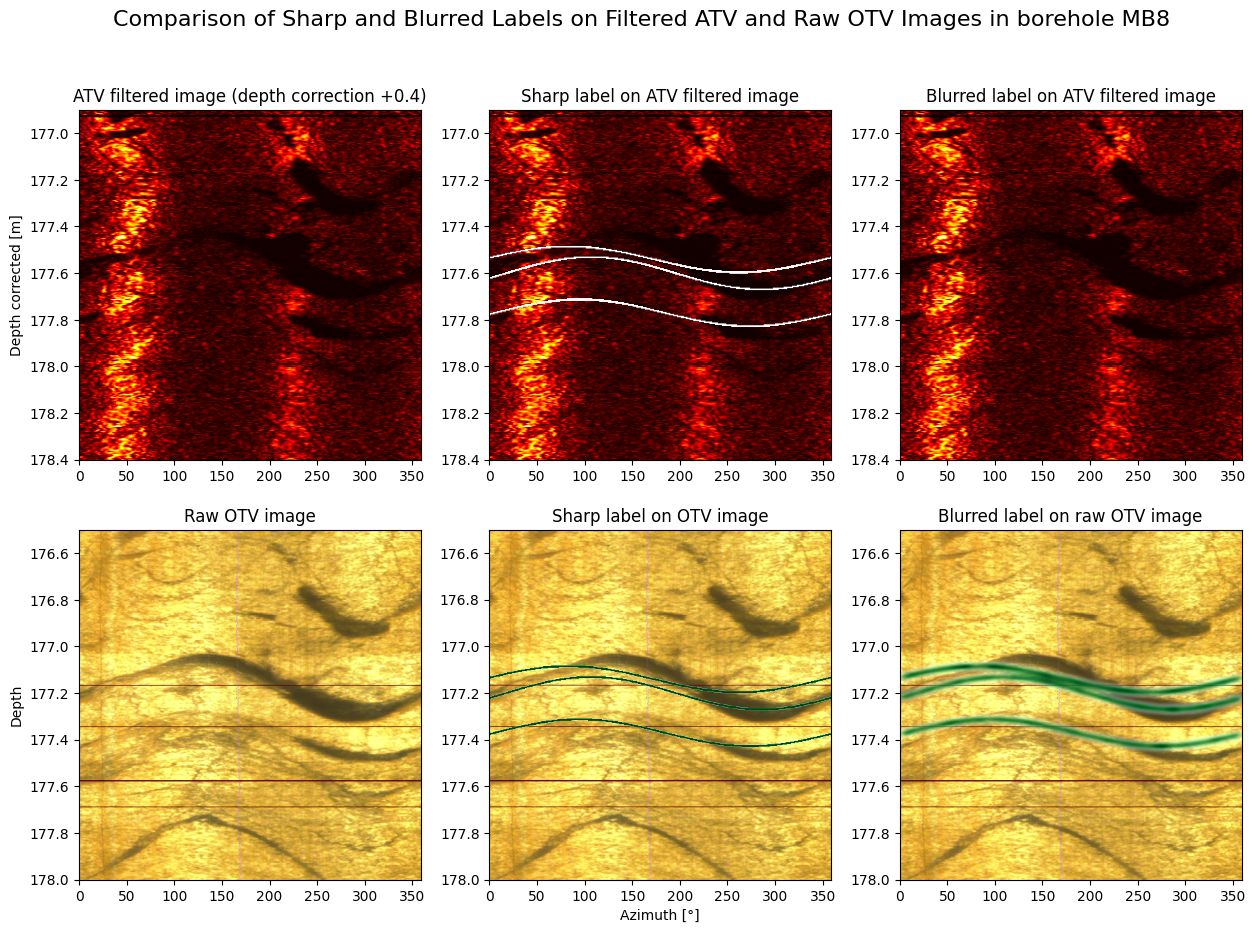

In [70]:
#Plotting cell
# tries plot with the filtered ATV image (SVD)
data_subset_svd_am = data_subset_svd_am, svd_decomp_am = remove_svd(data_subset_ATV, low_s=0, high_s=0)

#tries for plotting
import numpy as np
import matplotlib.pyplot as plt

data_subset_svd_am = replace_empty_measurements(data_subset_svd_am, 0)
# %% Plot the results and compare with a blurred mask
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].imshow(data_subset_svd_am, aspect='auto', extent=[0, 359, 178.40,176.90], cmap='hot')
axs[0,0].set_ylabel('Depth corrected [m]')
axs[0,0].set_title('ATV filtered image (depth correction +0.4)')

labels_raw_ATV = label1_atv + label2_atv + label3_atv #+ label4_atv + label5_atv
# Your existing imshow code
axs[0,1].imshow(data_subset_svd_am,
                aspect='auto',
               extent=[0, 359, 178.40,176.90],
                cmap='hot')
axs[0,1].imshow(labels_raw_ATV,
                aspect='auto',
               extent=[0, 359, 178.40,176.90],
                alpha=labels_raw_ATV,
                cmap='grey')
#axs[0,0].imshow(label1_atv + label2_atv,
              #cmap='grey',
              #aspect='auto',
              #extent=[0, 359, depth_vector_atv.max(), depth_vector_atv.min()],
              #alpha=0.3)

axs[0,1].set_title('Sharp label on ATV filtered image')

# Blur the label with a gaussian kernel

label1_blurred_atv = gaussian_blur(label1_atv, kernel_size=19)
label2_blurred_atv = gaussian_blur(label2_atv, kernel_size=19)
label3_blurred_atv = gaussian_blur(label3_atv, kernel_size=19)
#label4_blurred_atv = gaussian_blur(label4_atv, kernel_size=19)
#label5_blurred_atv = gaussian_blur(label5_atv, kernel_size=19)
labels_blurred_ATV = label1_blurred_atv + label2_blurred_atv + label3_blurred_atv # + label4_blurred_atv +label5_blurred_atv 

axs[0,2].imshow(data_subset_svd_am, aspect='auto', extent=[0, 359, 178.40,176.90], cmap='hot')
#axs[0,2].imshow(labels_blurred_ATV, aspect='auto', extent=[0, 359, 178.00,176.50], cmap='BuGn',
                #alpha=labels_blurred_ATV)
axs[0,2].set_title('Blurred label on ATV filtered image')

# plot normal label on OTV
axs[1,0].imshow(data_subset_otv, aspect='auto', extent=[0, 359, 178.00,176.50])
axs[1,0].set_ylabel('Depth')# Corrected [m]')
axs[1,0].set_title('Raw OTV image') # (depth correction of -0.2m)')


labels_raw_OTV = label1_otv + label2_otv + label3_otv #+ label4_otv + label5_otv
axs[1,1].imshow(data_subset_otv, aspect='auto', extent=[0, 359, 178.00,176.50])
axs[1,1].imshow(labels_raw_OTV,
             cmap='BuGn',
              aspect='auto',
              extent=[0, 359, depth_vector_otv.max(), depth_vector_otv.min()],
              alpha=labels_raw_OTV)
axs[1,1].set_title('Sharp label on OTV image')
axs[1,1].set_xlabel('Azimuth [°]')
# Plot data_subset_atv with blurred label
label1_blurred_otv = gaussian_blur(label1_otv, kernel_size=19)
label2_blurred_otv = gaussian_blur(label2_otv, kernel_size=19)
label3_blurred_otv = gaussian_blur(label3_otv, kernel_size=19)
#label4_blurred_otv = gaussian_blur(label4_otv, kernel_size=19)
#label5_blurred_otv = gaussian_blur(label5_otv, kernel_size=19)


labels_blurred_OTV = label1_blurred_otv + label2_blurred_otv + label3_blurred_otv #+ label4_blurred_otv + label5_blurred_otv
axs[1,2].imshow(data_subset_otv, 
                aspect='auto', 
                extent=[0, 359, 178.00,176.50])
axs[1,2].imshow(labels_blurred_OTV, 
                aspect='auto', 
                extent=[0, 359, 178.00,176.50],
# use the labels matrix as a tranparency mask for plotting the image
# add a command to choose the colormap for the labels
                cmap='BuGn',
                alpha = labels_blurred_OTV)

# zoom into the image to see the blurred label
#axs[1,1].set_xlim(50, 150)
#axs[1,1].set_ylim(158.8, 158.4)
axs[1,2].set_title('Blurred label on raw OTV image')

# Plot a column of the image before and after blurring with transparency
#axs[1, 1].plot(depth_vector_atv, label[:, 180], label='Original', alpha=1, color='black')
#axs[1, 1].plot(depth_vector_atv, label_blurred[:, 180], label='Blurred', alpha=0.5, color='red')
#axs[1, 1].legend()
#axs[1, 1].set_xlabel('Depth [m]')
#axs[1, 1].set_ylabel('Probability')
#axs[1, 1].set_xlim(118, 120)
plt.suptitle('Comparison of Sharp and Blurred Labels on Filtered ATV and Raw OTV Images in borehole MB8', fontsize=16)

plt.show()
#OTV = ATV - 0.3 m


In [28]:
#Figure for svd filtering
from deeplogger.importLASv3 import *
depth_subset_ATV = get_depth_only(file_name=file_atv_am, #you can also just put the number of the data location in the files list, which is "files[10]" for the amplitude MB3 and "files[5]" for the travel time MB3
               data_path=path_to_data)

depth_subset_ATV, data_subset_ATV, index = get_data_subset_from_depth_range(file_name=file_atv_am,
                                                                    data_path=path_to_data,
                                                                    data_type='atv',
                                                                    depth_range=[24.0, 25.0])
data_subset_ATV = data_subset_ATV.astype(float)



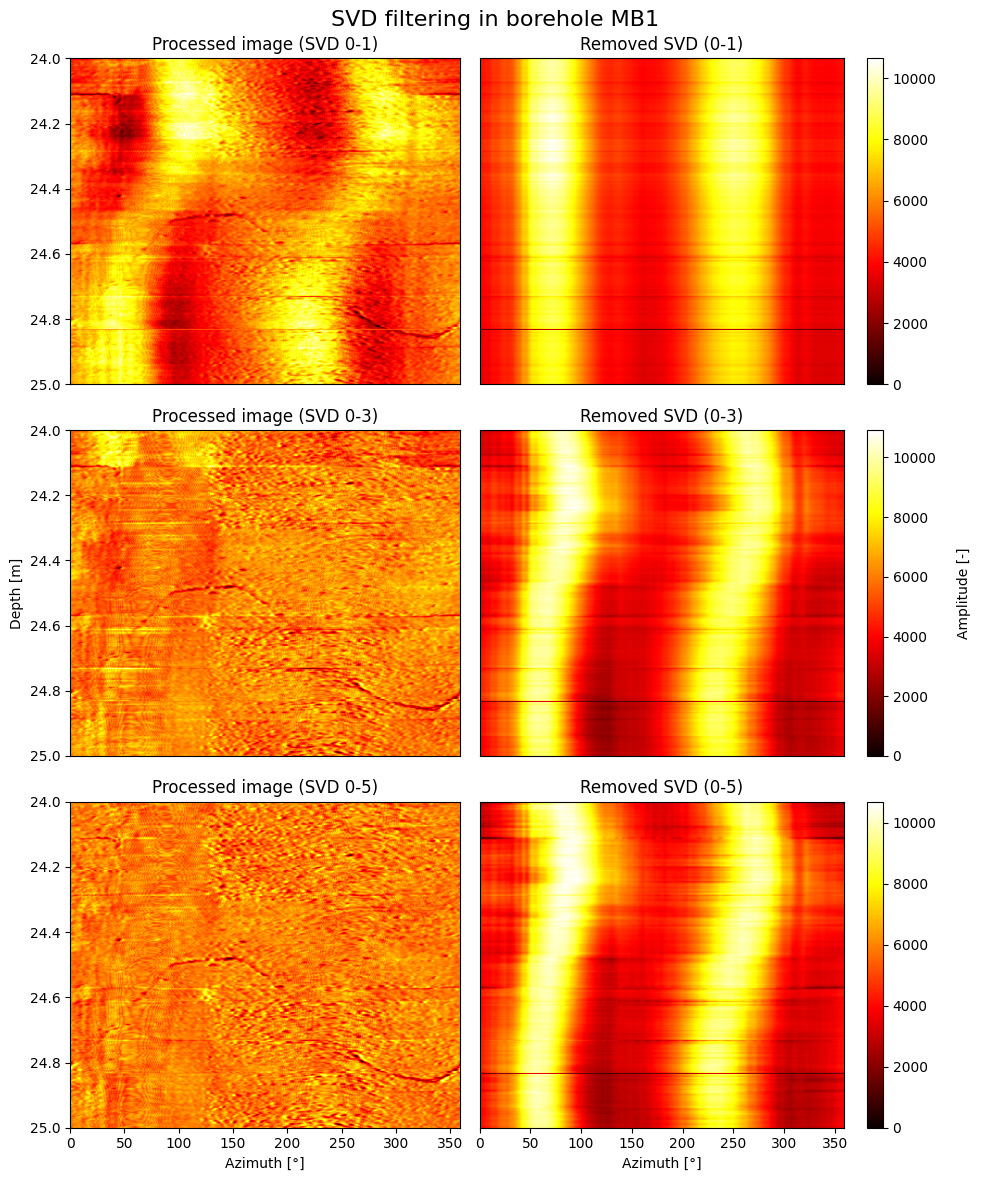

In [217]:
#Plotting cell
# tries plot with the filtered ATV image (SVD)
data_subset_svd_am_1 = data_subset_svd_am_1, svd_decomp_am_1 = remove_svd(data_subset_ATV, low_s=0, high_s=1)
data_subset_svd_am_3 = data_subset_svd_am_3, svd_decomp_am_3 = remove_svd(data_subset_ATV, low_s=0, high_s=3)
data_subset_svd_am_5 = data_subset_svd_am_5, svd_decomp_am_5 = remove_svd(data_subset_ATV, low_s=0, high_s=5)

#tries for plotting
import numpy as np
import matplotlib.pyplot as plt

data_subset_svd_am = replace_empty_measurements(data_subset_svd_am, 0)
# %% Plot the results and compare with a blurred mask
fig, axs = plt.subplots(3, 2, figsize=(10, 12), gridspec_kw={'width_ratios': [1.8, 2.1]})
axs[0,0].imshow(data_subset_svd_am_1, aspect='auto', extent=[0, 359, 25.0,24.0], cmap='hot')

axs[0,0].set_title('Processed image : Singular values removed 0-1')

# Your existing imshow code
im1 = axs[0,1].imshow(svd_decomp_am_1,
                aspect='auto',
               extent=[0, 359, 25.0, 24.0],
                cmap='hot')
#axs[0,0].imshow(label1_atv + label2_atv,
              #cmap='grey',
              #aspect='auto',
              #extent=[0, 359, depth_vector_atv.max(), depth_vector_atv.min()],
              #alpha=0.3)

axs[0,1].set_title('Removed SVD (0-1)')
axs[0, 1].set_yticks([])
axs[0, 0].set_xticks([])
axs[0, 1].set_xticks([])

axs[1,0].imshow(data_subset_svd_am_3, aspect='auto', extent=[0, 359, 25.0, 24.0], cmap='hot')
axs[1,0].set_title('Processed image : Singular values removed 0-3')
axs[1,0].set_ylabel('Depth [m]')
im2 = axs[1,1].imshow(svd_decomp_am_3, aspect='auto', extent=[0, 359, 25.0, 24.0], cmap='hot')
# plot normal label on OTV
axs[1,1].set_title('Removed SVD (0-3)')
axs[1, 1].set_yticks([])
axs[1, 0].set_xticks([])
axs[1, 1].set_xticks([])


axs[2,0].imshow(data_subset_svd_am_5, aspect='auto', extent=[0, 359, 25.0, 24.0], cmap='hot')
axs[2,0].set_title('Processed image : Singular values removed 0-5')
im3 = axs[2,1].imshow(svd_decomp_am_5, aspect='auto', extent=[0, 359, 25.0, 24.0], cmap='hot')
# plot normal label on OTV
axs[2,1].set_title('Removed SVD (0-5)')

axs[2,0].set_xlabel('Azimuth [°]')
axs[2,1].set_xlabel('Azimuth [°]')
axs[2, 1].set_yticks([])


axs[0, 0].set_title('Processed image (SVD 0-1)')
axs[1, 0].set_title('Processed image (SVD 0-3)')
axs[2, 0].set_title('Processed image (SVD 0-5)')
plt.suptitle('SVD filtering in borehole MB1', fontsize=16)

# Add colorbars to the subplots
cbar1 = fig.colorbar(im1, ax=axs[0,1])
cbar2 = fig.colorbar(im2, ax=axs[1,1])
cbar3 = fig.colorbar(im3, ax=axs[2,1])
cbar2.set_label('Amplitude [-]', rotation=90, labelpad=15)
# Adjust layout for better visualization
plt.tight_layout()

plt.show()